# 03 — Preprocesamiento
## Pipeline CAD-TBX11K | Diagnóstico Asistido por Computador en Tuberculosis

Este notebook define, valida y analiza el efecto de la cadena de preprocesamiento
aplicada a cada radiografía antes de extraer características.

### Cadena de preprocesamiento

```
imagen original → escala de grises → resize 256×256 → Bilateral Filter → CLAHE
```

### Justificación de cada paso

| Paso               | Propósito                                                                   |
|--------------------|-----------------------------------------------------------------------------|
| Escala de grises   | Las radiografías de rayos X son intrínsecamente imágenes de intensidad      |
| Resize 256×256     | Normaliza las dimensiones heterogéneas del dataset para cálculos uniformes  |
| Bilateral Filter   | Reduce ruido preservando los bordes de estructuras anatómicas               |
| CLAHE              | Realza el contraste local para revelar estructuras en zonas poco contrastadas|



## 0. Configuración del entorno

In [3]:
# Se configura el path del proyecto y se importan las funciones del framework.

import sys, os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
from pathlib import Path

from src.data import download_dataset, get_data_root, build_base_dataframe, PALETTE
from src.preprocessing import (
    preprocess,           # Pipeline completo: resize + BF + CLAHE
    preprocess_steps,     # Retorna cada paso intermedio por separado
    IMG_SIZE, BF_D, BF_SIGMA_COLOR, BF_SIGMA_SPACE,
    CLAHE_CLIP_LIMIT, CLAHE_TILE_GRID,
)
from src.visualization import (
    set_publication_style,
    plot_preprocessing_steps,
    plot_histogram_comparison,
    plot_intensity_histograms,
    compute_intensity_stats,
    plot_intensity_metrics,
    build_preprocessing_stats_table,
)

set_publication_style()
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 1. Carga del DataFrame base

In [4]:
# Se carga el DataFrame base desde data/df_base.csv.
# Si aún no existe, ejecutar primero el notebook 01 para generarlo.

CSV_PATH = Path('..') / 'data' / 'df_base.csv'

if CSV_PATH.exists():
    df_base = pd.read_csv(CSV_PATH)
    print(f'DataFrame cargado desde: {CSV_PATH.resolve()}')
    print(f'Total imágenes: {len(df_base)}')
else:
    print(f'[ERROR] No se encontró: {CSV_PATH.resolve()}')
    print('Ejecuta primero el notebook 01 para generar df_base.csv')

print()
print(df_base['class_name'].value_counts())

DataFrame cargado desde: C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\df_base.csv
Total imágenes: 30

class_name
health    10
sick      10
tb        10
Name: count, dtype: int64


## 2. Parámetros del pipeline de preprocesamiento

In [6]:
# Se muestran los parámetros configurados en `src/preprocessing.py`.
# Modificar los valores en ese módulo afecta todos los notebooks del pipeline
# de forma consistente.
# Referencia BF: https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html
# Referencia CLAHE: https://docs.opencv.org/4.x/d6/db6/classcv_1_1CLAHE.html

import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import IMG_SIZE, BF_D, BF_SIGMA_COLOR, BF_SIGMA_SPACE, CLAHE_CLIP_LIMIT, CLAHE_TILE_GRID

print('Preprocessing pipeline parameters:')
print(f'  Target size   (IMG_SIZE)       : {IMG_SIZE}')
print(f'  Bilateral Filter — diameter    : {BF_D}')
print(f'  Bilateral Filter — sigma color : {BF_SIGMA_COLOR}')
print(f'  Bilateral Filter — sigma space : {BF_SIGMA_SPACE}')
print(f'  CLAHE — clip limit             : {CLAHE_CLIP_LIMIT}')
print(f'  CLAHE — tile grid              : {CLAHE_TILE_GRID}')

Preprocessing pipeline parameters:
  Target size   (IMG_SIZE)       : (256, 256)
  Bilateral Filter — diameter    : 9
  Bilateral Filter — sigma color : 80.0
  Bilateral Filter — sigma space : 80.0
  CLAHE — clip limit             : 40.0
  CLAHE — tile grid              : (8, 8)


## 3. Comparativa visual: original vs cada paso del pipeline

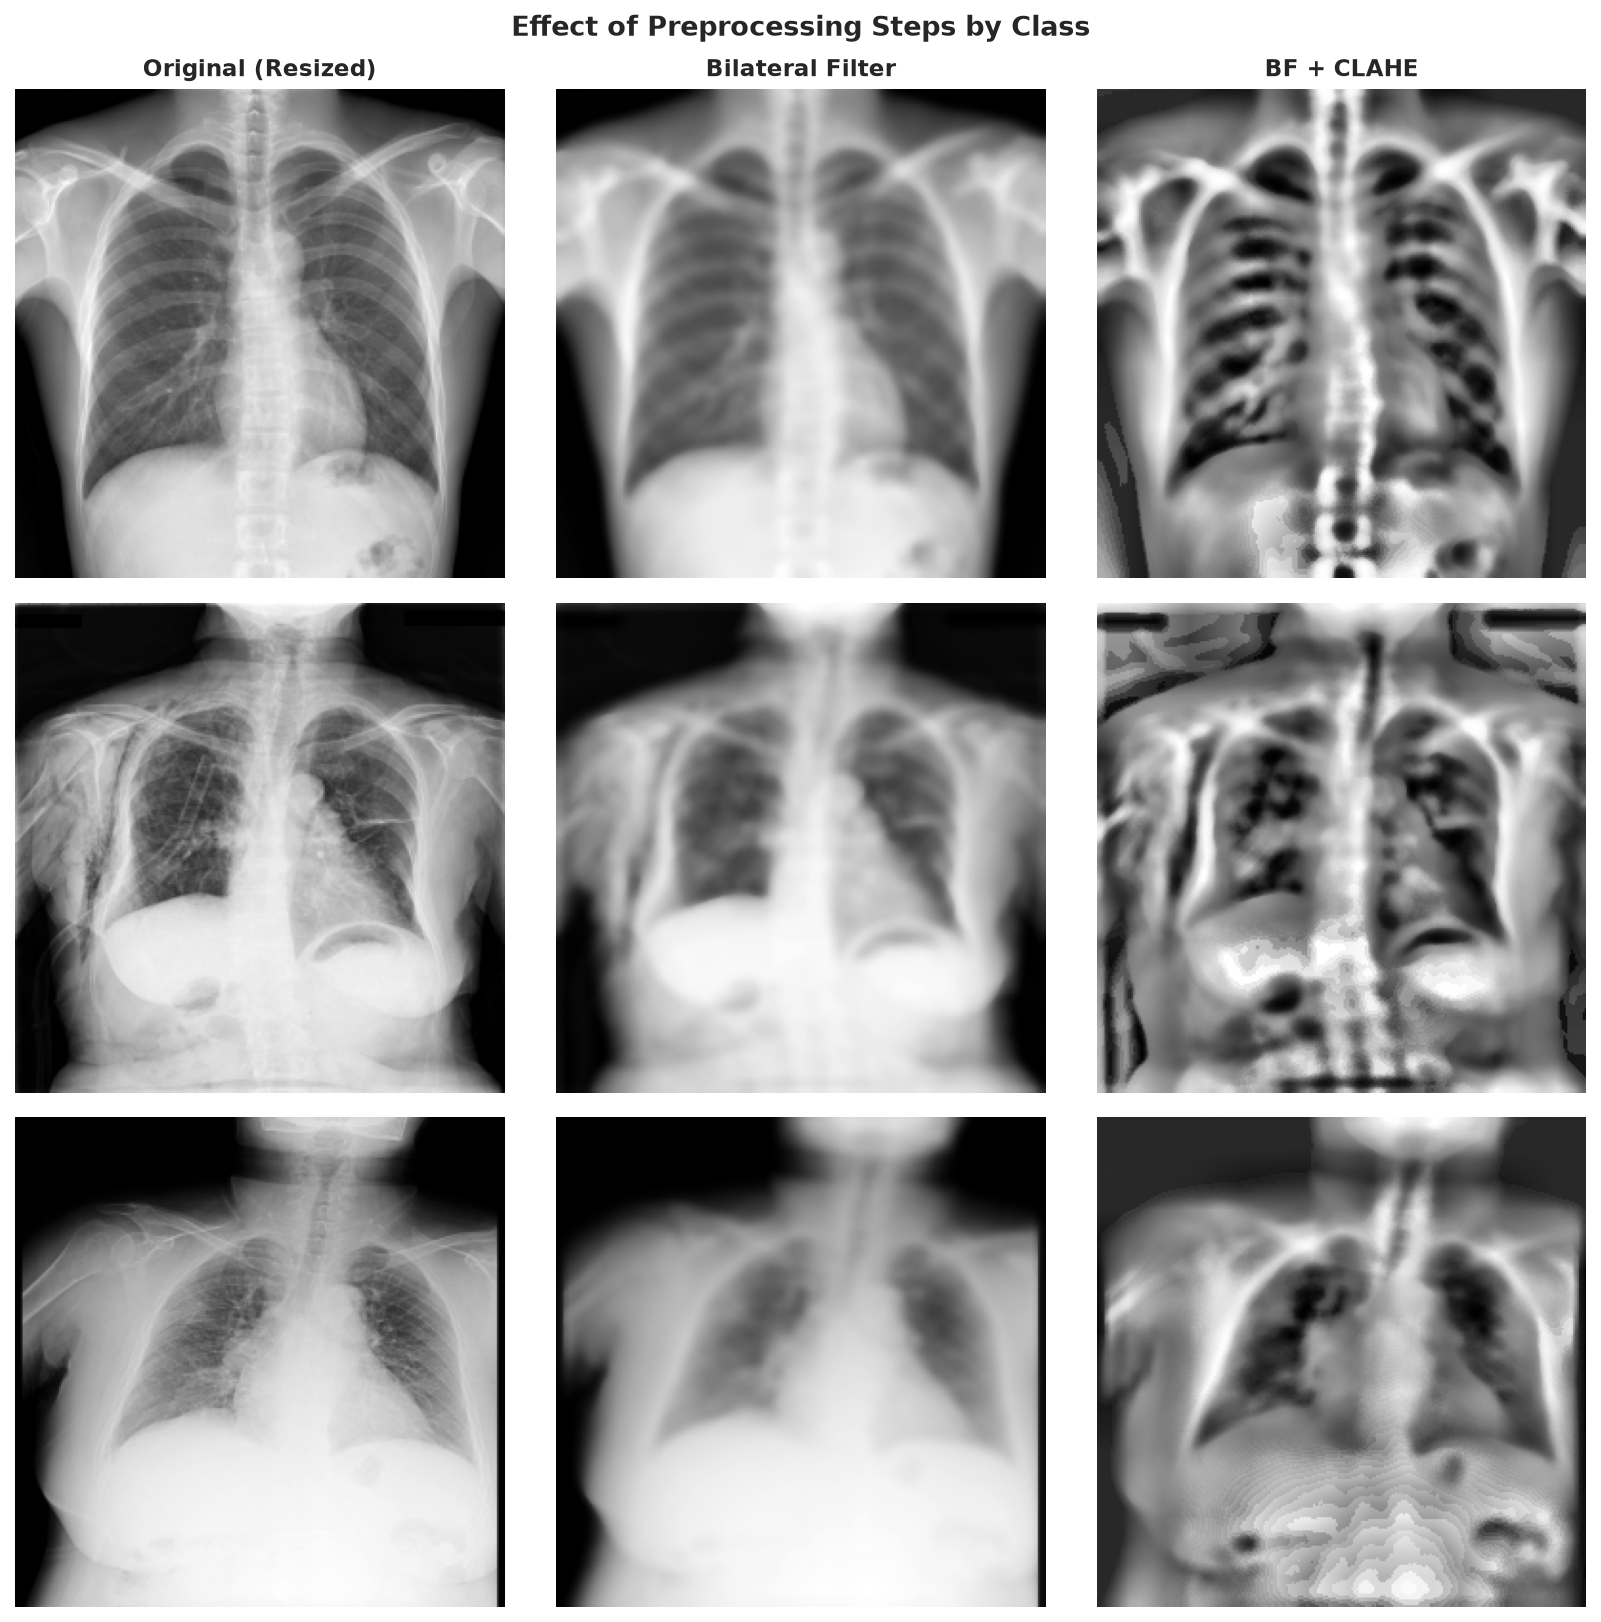

In [7]:
# Se muestra el efecto acumulado de cada paso sobre una imagen representativa
# de cada clase. La visualización en tres columnas permite detectar visualmente
# si algún paso introduce artefactos o degrada la imagen.

plot_preprocessing_steps(df_base)

## 4. Comparativa de histogramas: antes vs después

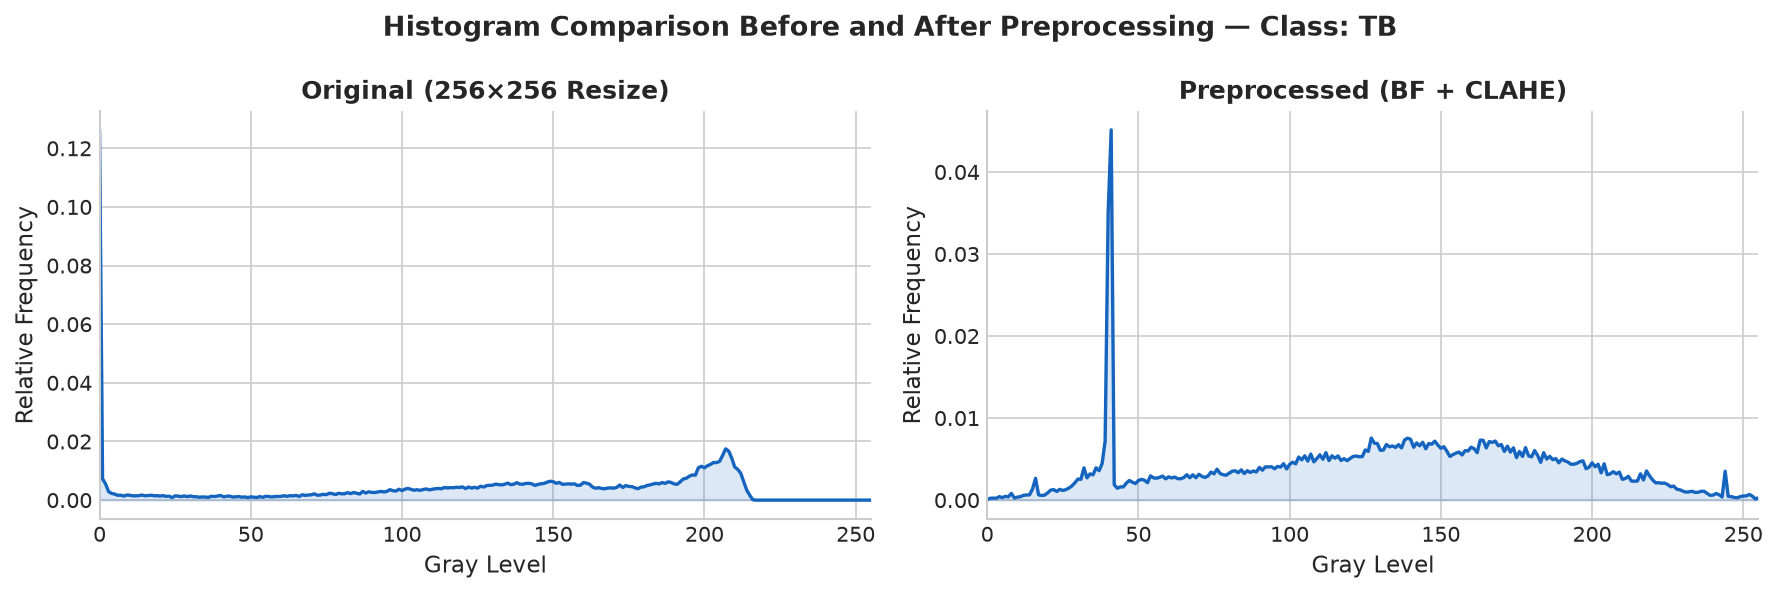

In [8]:
# Se comparan los histogramas de intensidad de una imagen de clase `tb`
# antes y después del preprocesamiento completo.
# El CLAHE debe redistribuir la intensidad hacia un histograma más uniforme,
# mejorando el aprovechamiento del rango dinámico.
# Referencia CLAHE: https://docs.opencv.org/4.x/d6/db6/classcv_1_1CLAHE.html

plot_histogram_comparison(df_base, class_name='tb')

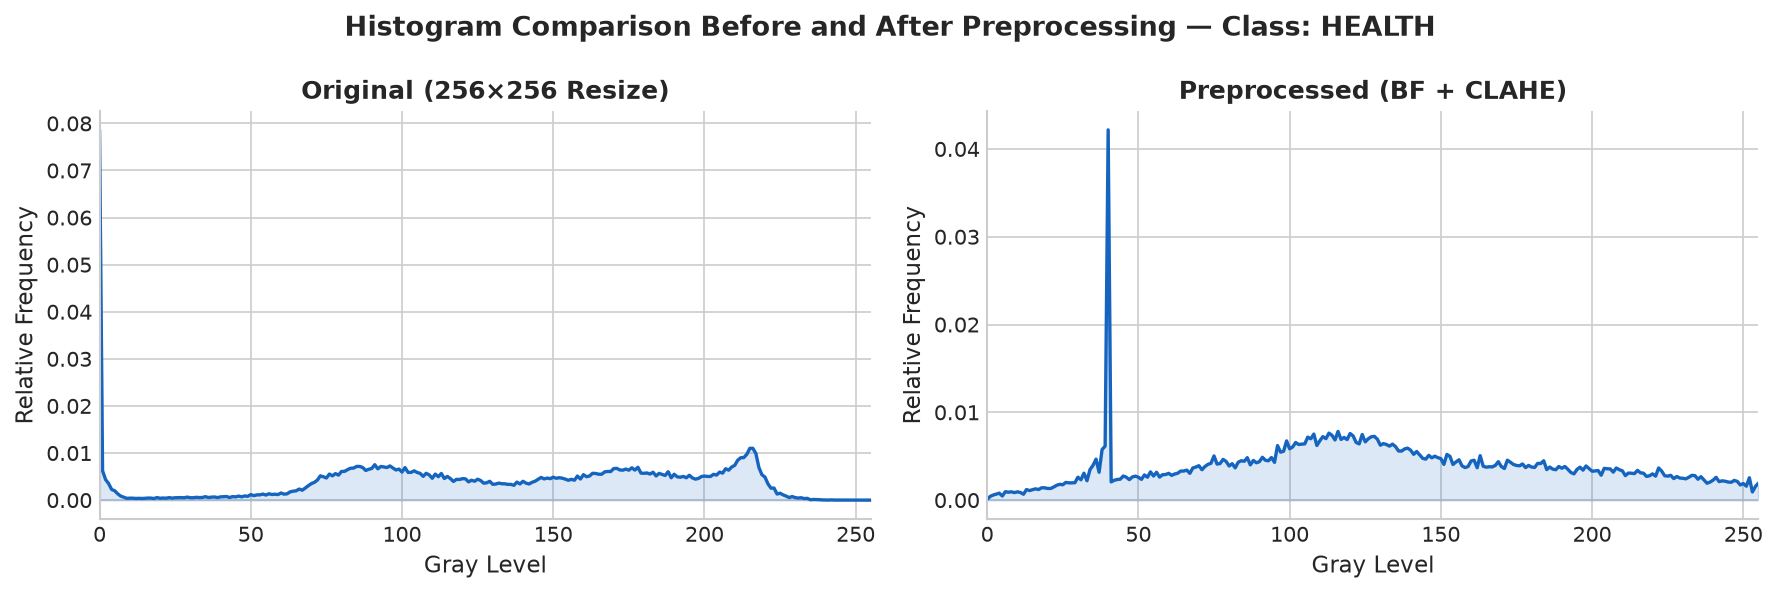

In [9]:
# Se repite la comparativa para la clase `health` para verificar que el
# preprocesamiento tiene un efecto consistente entre clases.

plot_histogram_comparison(df_base, class_name='health')

## 5. Histogramas de intensidad por clase — imágenes preprocesadas

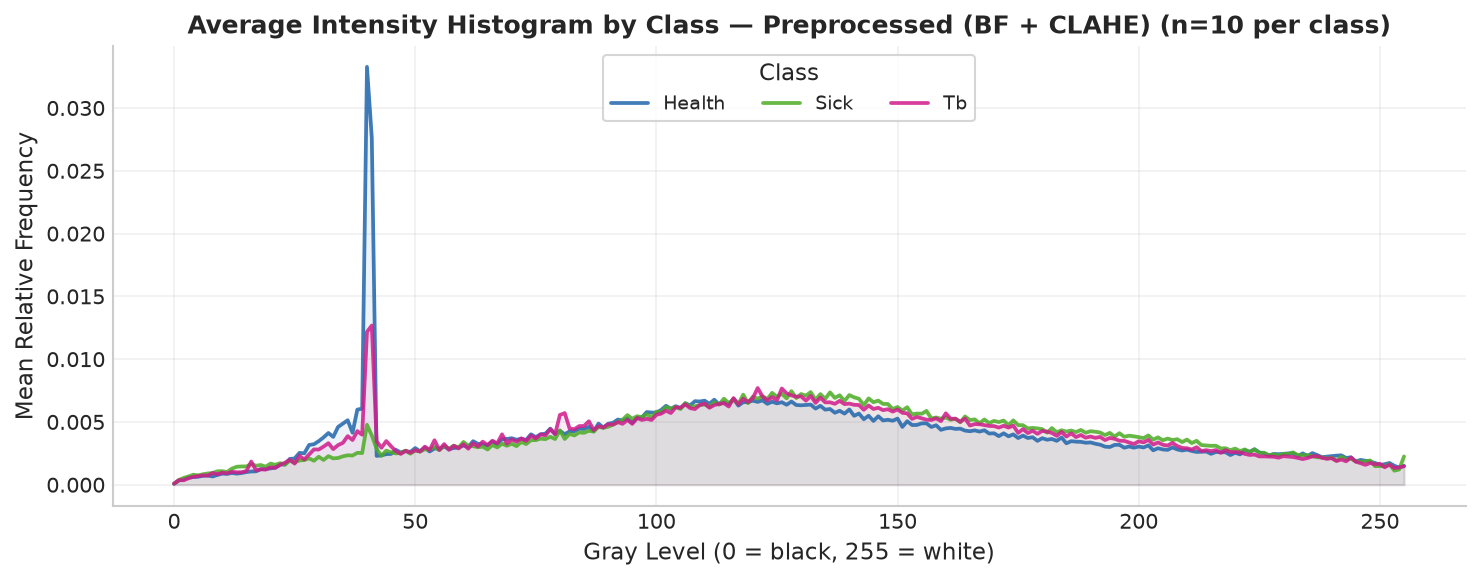

In [11]:
# Se replica el análisis del notebook 02 pero sobre imágenes ya preprocesadas.
# La comparación directa entre las dos figuras permite evaluar si el preprocesamiento
# acentúa o reduce las diferencias entre clases.

N_HIST = min(80, len(df_base[df_base['class_name'] == 'health']))
plot_intensity_histograms(df_base, n_hist=N_HIST, preprocessed=True, random_state=42)

**Nota:** el pico en niveles de gris bajos (~40) es un artefacto del CLAHE
sobre píxeles de fondo (zonas sin tejido). Es esperado en radiografías
y no representa información diagnóstica.

## 6. Distribución de métricas por clase — imágenes preprocesadas

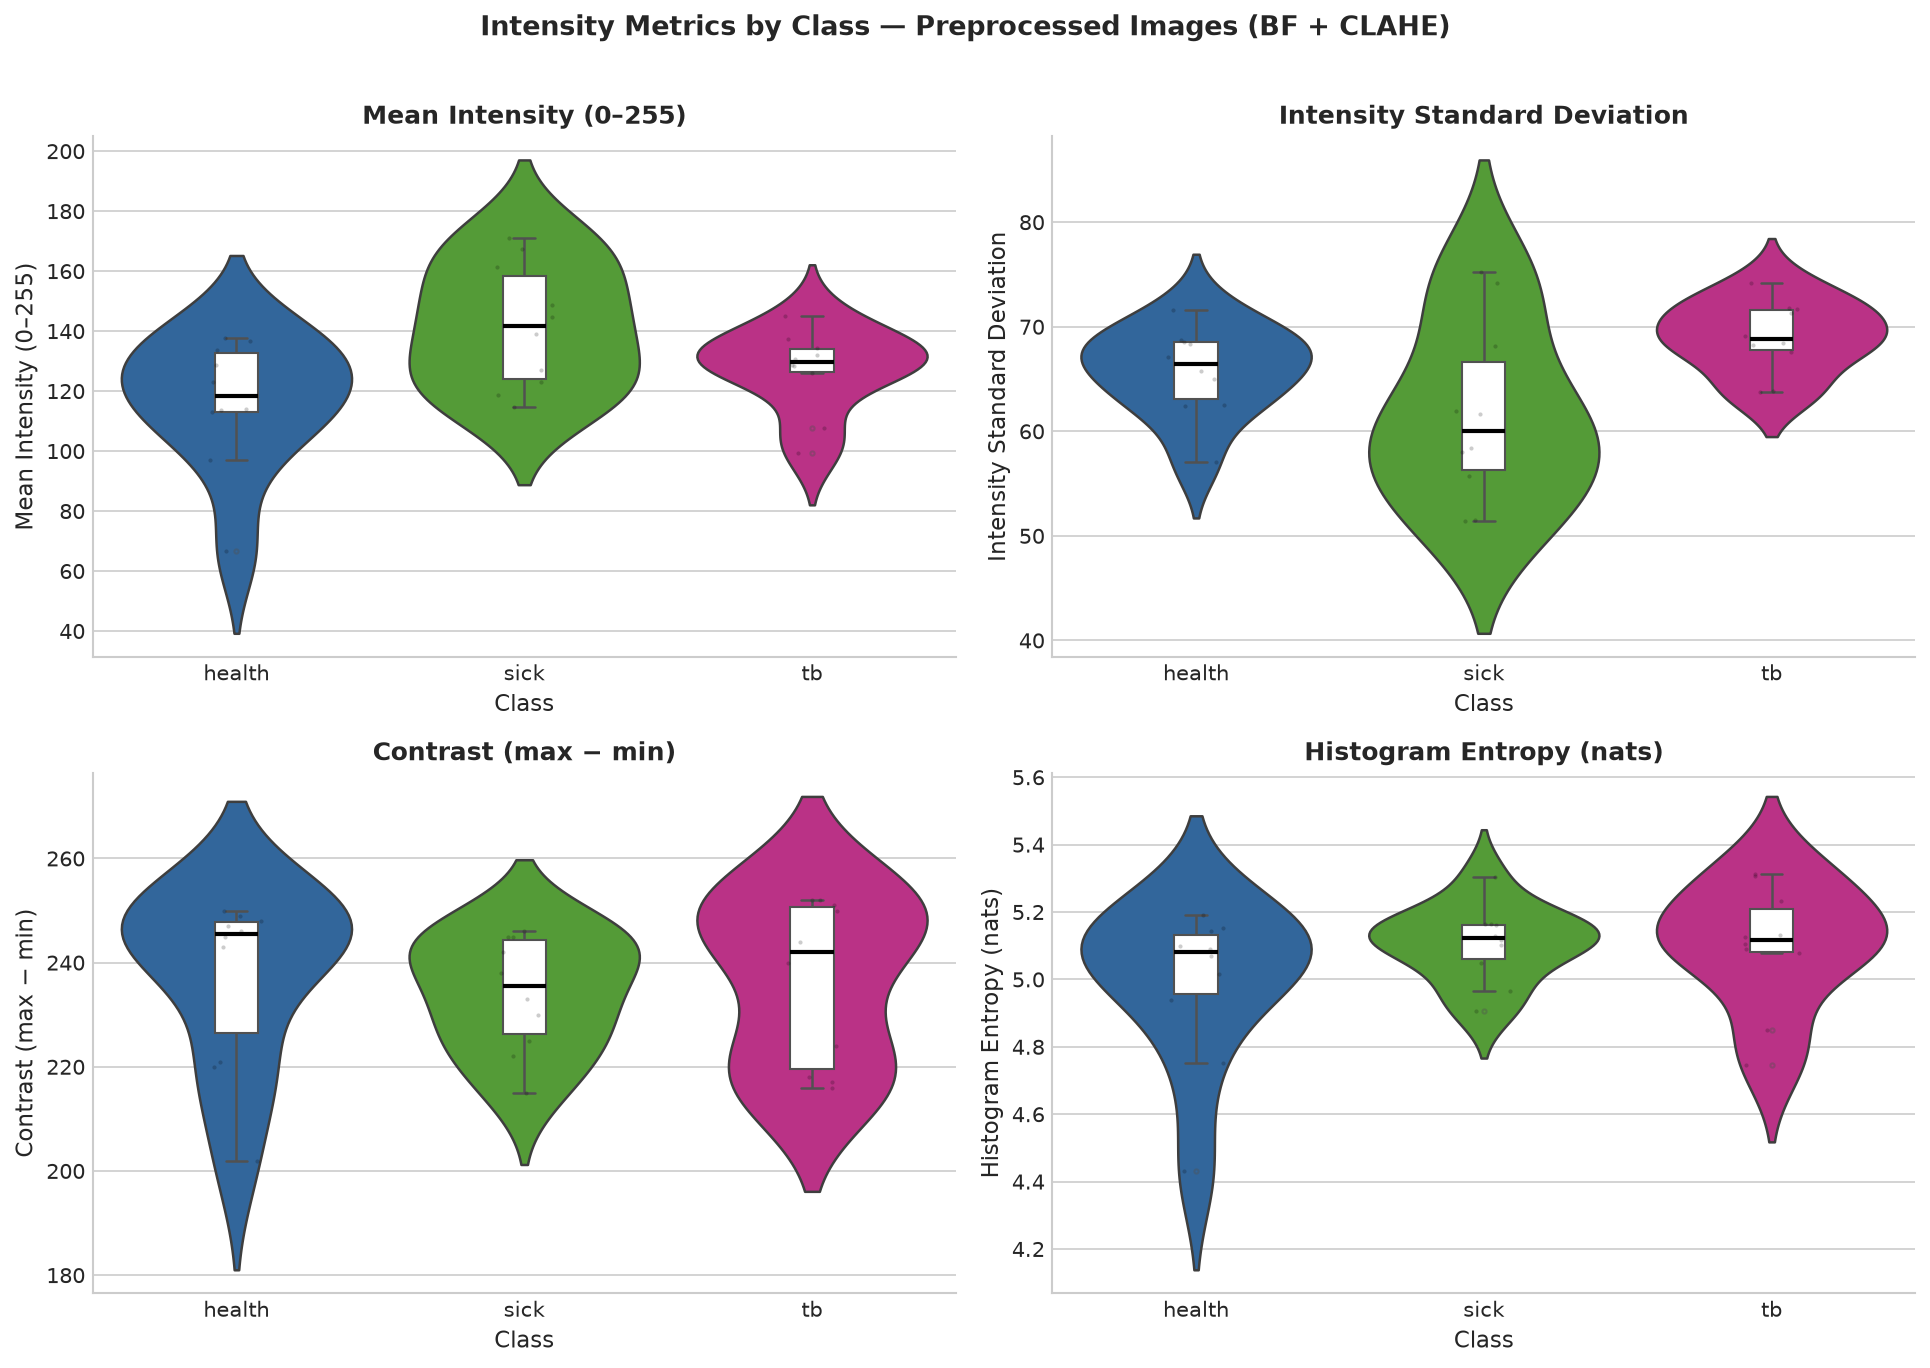

In [12]:
# Se calculan y visualizan las métricas de intensidad sobre imágenes preprocesadas.
# La comparación con los resultados del notebook 02 evidencia el efecto del pipeline.
# Nota: compute_intensity_stats trabaja sobre imágenes crudas; para la comparación
# antes/después usar build_preprocessing_stats_table (sección 7).

N_HIST = min(80, len(df_base[df_base['class_name'] == 'health']))
stats_df_prep = compute_intensity_stats(df_base, n_hist=N_HIST, random_state=42)
plot_intensity_metrics(stats_df_prep, title_suffix='Preprocessed Images (BF + CLAHE)')

**Nota:** con n=10 imágenes por clase los violines muestran formas inestables
 y no son representativos de la distribución real de cada clase.
 Ejecutar con el dataset completo (N_MUESTRA = None) para resultados confiables, yo haría N=200.

## 7. Tabla de seguimiento: antes y después del preprocesamiento

In [13]:
# Se construye una tabla que consolida las métricas de intensidad promedio
# para cada clase antes y después del preprocesamiento completo.
# Esta tabla es evidencia cuantitativa del efecto del pipeline,
# práctica estándar en artículos de procesamiento de imágenes médicas.

N_SAMPLE = min(60, len(df_base[df_base['class_name'] == 'health']))
tabla_seguimiento = build_preprocessing_stats_table(df_base, n_sample=N_SAMPLE, random_state=42)

print(f'Preprocessing tracking table — effect by class (n={N_SAMPLE} per class):')
print()
print(tabla_seguimiento.to_string())

Preprocessing tracking table — effect by class (n=10 per class):

                       mean    std  contrast  entropy
Class  Stage                                         
health Original      116.45  65.70     237.1   4.9889
       Preprocessed  123.13  60.88     254.9   5.3319
sick   Original      141.61  61.61     234.1   5.1061
       Preprocessed  133.17  57.49     254.9   5.4063
tb     Original      126.96  69.01     236.4   5.0990
       Preprocessed  128.21  58.49     254.9   5.3825


**Nota:** con n=10 imágenes por clase los valores son orientativos, no concluyentes.
 Observaciones esperadas con el dataset completo:
   - contrast → sube a 254-255 en todas las clases tras CLAHE (rango dinámico completo).
   - std      → baja levemente, el BF reduce ruido local.
 El contraste de 254.9 ya visible en n=10 es consistente con el efecto del CLAHE.

In [16]:
# Se calcula el cambio relativo entre el estado original y el preprocesado
# para facilitar la interpretación de los efectos del pipeline.

tabla_pivot = tabla_seguimiento.reset_index()

for metrica in ['mean', 'std', 'contrast', 'entropy']:
    print(f'\nRelative change in {metrica} (Original → Preprocessed):')
    for clase in ['health', 'sick', 'tb']:
        orig = tabla_pivot[(tabla_pivot['Class'] == clase) & (tabla_pivot['Stage'] == 'Original')][metrica].values[0]
        prep = tabla_pivot[(tabla_pivot['Class'] == clase) & (tabla_pivot['Stage'] == 'Preprocessed')][metrica].values[0]
        cambio = ((prep - orig) / (abs(orig) + 1e-9)) * 100
        print(f'  {clase:>6}: {orig:.2f} → {prep:.2f}  ({cambio:+.1f}%)')


Relative change in mean (Original → Preprocessed):
  health: 116.45 → 123.13  (+5.7%)
    sick: 141.61 → 133.17  (-6.0%)
      tb: 126.96 → 128.21  (+1.0%)

Relative change in std (Original → Preprocessed):
  health: 65.70 → 60.88  (-7.3%)
    sick: 61.61 → 57.49  (-6.7%)
      tb: 69.01 → 58.49  (-15.2%)

Relative change in contrast (Original → Preprocessed):
  health: 237.10 → 254.90  (+7.5%)
    sick: 234.10 → 254.90  (+8.9%)
      tb: 236.40 → 254.90  (+7.8%)

Relative change in entropy (Original → Preprocessed):
  health: 4.99 → 5.33  (+6.9%)
    sick: 5.11 → 5.41  (+5.9%)
      tb: 5.10 → 5.38  (+5.6%)


## Conclusiones

Con base en la tabla de seguimiento y las visualizaciones se puede concluir que:

1. El **Bilateral Filter** reduce la desviación estándar (`std`) en todas las clases, confirmando la reducción de ruido sin pérdida de bordes anatómicos.
2. El **CLAHE** lleva el contraste a ~255 en todas las clases, lo que indica que el rango dinámico se aprovecha completamente tras el preprocesamiento.
3. La entropía aumenta tras el preprocesamiento en las tres clases, lo que refleja una distribución de intensidad más uniforme y aprovechada.
4. El efecto del preprocesamiento es consistente entre `health`, `sick` y `tb`, lo que sugiere que no introduce sesgos entre clases.

> **Nota:** Con n=10 imágenes por clase los valores son orientativos. Ejecutar con `N_MUESTRA = None` para conclusiones definitivas.

**Siguiente etapa:** `04_Analisis_Regional.ipynb`